In [1]:

import os
import random
from collections import defaultdict

import numpy as np
import pandas as pd



from matplotlib import pyplot as plt



from sklearn.cluster import KMeans



from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb



from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline



from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor, MLPClassifier

import xgboost as xgb
import lightgbm as lgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data




In [2]:
class DatasetLoader:
    def __init__(self, dataset_name):
        self.dataset_name = dataset_name
        self.base_dir = os.path.join(os.getcwd(), dataset_name)

    def load(self):
        if self.dataset_name == "MDRF":
            return self._load_mdrf()
        elif self.dataset_name == "LSGT":
            return self._load_lsgt()
        elif self.dataset_name == "PSnoD":
            return self._load_psnod()
        else:
            raise ValueError("Unsupported dataset")

    def _load_mdrf(self):
        disease = pd.read_csv(os.path.join(self.base_dir, 'disease_semantic_similarity.csv'))
        snoRNA = pd.read_csv(os.path.join(self.base_dir, 'snoRNA_similarity_.csv'))
        relation = pd.read_csv(os.path.join(self.base_dir, 'known_snoRNA_disease.csv'))

        return (
            disease.iloc[:, 1:].values,
            snoRNA.iloc[:, :].values,
            relation.iloc[:, 1:].values
        )

    def _load_lsgt(self):
        disease = pd.read_csv(os.path.join(self.base_dir, 'disease_similarity.csv'))
        snoRNA = pd.read_csv(os.path.join(self.base_dir, 'snoRNA_similarity.csv'))
        relation = pd.read_csv(os.path.join(self.base_dir, 'known_snoRNA_disease.csv'))

        return (
            disease.iloc[:, 1:].values,
            snoRNA.iloc[:, 1:].values,
            relation.iloc[:, 1:].T.values
        )

    def _load_psnod(self):
        disease = pd.read_csv(os.path.join(self.base_dir, 'disease_sim_graph_filtered.csv'))
        snoRNA = pd.read_csv(os.path.join(self.base_dir, 'snoRNA_4mer_similarity.csv'))
        relation = pd.read_csv(os.path.join(self.base_dir, 'relationship_matrix_filtered.csv'))

        return (
            disease.iloc[:, 1:].values,
            snoRNA.iloc[:, 1:].values,
            relation.iloc[:, 1:].T.values
            
        )


In [3]:
class NegativeSampler:
    def __init__(self, disease_sim, rna_sim, adj_matrix, n_clusters=23, random_state=0):
        self.disease_sim = disease_sim
        self.rna_sim = rna_sim
        self.adj_matrix = adj_matrix
        self.n_clusters = n_clusters
        self.random_state = random_state

    def sample(self):
        known, unknown = self._split_known_unknown()
        major = self._build_feature_vectors(unknown)

        kmeans = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state
        ).fit(major)

        cluster_map = defaultdict(list)
        for pair, label in zip(unknown, kmeans.labels_):
            cluster_map[label].append(pair)

        sampled_unknown = []
        target_size = len(known)

        for c in cluster_map:
            n = int((len(cluster_map[c]) / len(unknown)) * target_size)
            sampled_unknown.extend(random.sample(cluster_map[c], min(n, len(cluster_map[c]))))

        return known, sampled_unknown

    def _split_known_unknown(self):
        known, unknown = [], []
        for r in range(self.adj_matrix.shape[0]):
            for d in range(self.adj_matrix.shape[1]):
                if self.adj_matrix[r, d] == 0:
                    unknown.append((r, d))
                else:
                    known.append((r, d))
        return known, unknown

    def _build_feature_vectors(self, pairs):
        features = []
        for r, d in pairs:
            a = self.disease_sim[d].tolist()
            b = self.rna_sim[r].tolist()
            features.append(a + b)
        return features


In [4]:
class AssociationDatasetBuilder:
    def __init__(self, disease_sim, rna_sim):
        self.disease_sim = disease_sim
        self.rna_sim = rna_sim

    def build(self, known, sampled_unknown):
        dataset = known + sampled_unknown

        X, y = [], []
        known_set = set(known)

        for r, d in dataset:
            a = self.disease_sim[d].tolist()
            b = self.rna_sim[r].tolist()
            X.append(a + b)
            y.append(1 if (r, d) in known_set else 0)

        return np.array(X), np.array(y)


In [5]:
class GBDTFeatureEncoder:
    def __init__(self, gbdt_model):
        self.gbdt = gbdt_model
        self.encoder = OneHotEncoder()

    def fit(self, X):
        leaf_indices = self.gbdt.apply(X)[:, :, 0]
        self.encoder.fit(leaf_indices)
        return self

    def transform(self, X):
        leaf_indices = self.gbdt.apply(X)[:, :, 0]
        return self.encoder.transform(leaf_indices)

    def fit_transform(self, X):
        leaf_indices = self.gbdt.apply(X)[:, :, 0]
        return self.encoder.fit_transform(leaf_indices)


In [6]:
from abc import ABC, abstractmethod

class HybridModel(ABC):
    """
    Encoder + classifier abstraction
    """

    @abstractmethod
    def fit_encoder(self, X, y):
        pass

    @abstractmethod
    def transform(self, X):
        pass

    @abstractmethod
    def get_estimator(self):
        pass

    @abstractmethod
    def get_param_grid(self):
        pass


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone

class RF_SVM_Model(HybridModel):
    def __init__(self, rf_params, svm_pipeline, svm_param_grid):
        self.rf = RandomForestClassifier(**rf_params)
        self.ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self.svm_pipeline = svm_pipeline
        self.param_grid = svm_param_grid

    def fit_encoder(self, X, y):
        self.rf.fit(X, y)
        leaf = self.rf.apply(X)
        self.ohe.fit(leaf)

    def transform(self, X):
        leaf = self.rf.apply(X)
        return self.ohe.transform(leaf)

    def get_estimator(self):
        return clone(self.svm_pipeline)

    def get_param_grid(self):
        return self.param_grid


In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone

class GBDT_SVM_Model(HybridModel):
    def __init__(self, gbdt_params, svm_pipeline, svm_param_grid):
        self.gbdt = GradientBoostingClassifier(**gbdt_params)
        self.ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self.svm_pipeline = svm_pipeline
        self.param_grid = svm_param_grid

    def fit_encoder(self, X, y):
        self.gbdt.fit(X, y)
        leaf = self.gbdt.apply(X)[:, :, 0]
        self.ohe.fit(leaf)

    def transform(self, X):
        leaf = self.gbdt.apply(X)[:, :, 0]
        return self.ohe.transform(leaf)

    def get_estimator(self):
        return clone(self.svm_pipeline)

    def get_param_grid(self):
        return self.param_grid


In [9]:
import xgboost as xgb

class XGB_SVM_Model(HybridModel):

    def __init__(self, xgb_params, svm_pipeline, svm_param_grid):
        self.xgb = xgb.XGBClassifier(**xgb_params, eval_metric="logloss")
        self.ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self.svm_pipeline = svm_pipeline
        self.param_grid = svm_param_grid

    def fit_encoder(self, X, y):
        self.xgb.fit(X, y)
        leaf = self.xgb.apply(X)
        self.ohe.fit(leaf)

    def transform(self, X):
        return self.ohe.transform(self.xgb.apply(X))

    def get_estimator(self):
        return clone(self.svm_pipeline)

    def get_param_grid(self):
        return self.param_grid


In [10]:
class AE_SVM_Model(HybridModel):

    def __init__(self, latent_dim=32, ae_max_iter=500):
        self.ae = MLPRegressor(
            hidden_layer_sizes=(latent_dim,),
            activation="relu",
            solver="adam",
            max_iter=ae_max_iter,
            random_state=42
        )

        self.svm_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", probability=True))
        ])

        self.param_grid = {
            "svm__C": [0.1, 1, 10],
            "svm__gamma": ["scale", 0.01, 0.001]
        }

    def fit_encoder(self, X, y):
        self.ae.fit(X, X)

    def transform(self, X):
        return self.ae.predict(X)

    def get_estimator(self):
        return clone(self.svm_pipeline)

    def get_param_grid(self):
        return self.param_grid

In [11]:
class LGBM_LR_Model(HybridModel):

    def __init__(self):
        self.lgbm = lgb.LGBMClassifier(n_estimators=200)
        self.lr = LogisticRegression(max_iter=1000)

    def fit_encoder(self, X, y):
        self.lgbm.fit(X, y)

    def transform(self, X):
        return self.lgbm.predict(X, pred_leaf=True)

    def get_estimator(self):
        return clone(self.lr)

    def get_param_grid(self):
        return {"C": [0.1, 1, 10]}

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

class ModelFactory:
    @staticmethod
    def svm_rbf():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", probability=True))
        ])

        param_grid = {
            "svm__C": [0.1, 1, 10],
            "svm__gamma": ["scale", 0.01, 0.001]
        }

        return pipeline, param_grid


In [13]:
class ModelEvaluator:
    def __init__(self, hybrid_model, n_splits=5, scoring="roc_auc", random_state=42):
        self.model = hybrid_model
        self.cv = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=random_state
        )
        self.scoring = scoring

    def evaluate(self, X, y):
        aucs, accs = [], []
        y_true, y_pred = [], []

        for fold, (train_idx, test_idx) in enumerate(self.cv.split(X, y), 1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # ✅ Fit encoder ONLY on training fold
            self.model.fit_encoder(X_train, y_train)

            X_train_enc = self.model.transform(X_train)
            X_test_enc = self.model.transform(X_test)

            grid = GridSearchCV(
                estimator=self.model.get_estimator(),
                param_grid=self.model.get_param_grid(),
                scoring=self.scoring,
                cv=3,
                n_jobs=-1
            )

            grid.fit(X_train_enc, y_train)

            best = grid.best_estimator_
            probs = best.predict_proba(X_test_enc)[:, 1]
            preds = best.predict(X_test_enc)

            aucs.append(roc_auc_score(y_test, probs))
            accs.append(best.score(X_test_enc, y_test))

            y_true.extend(y_test)
            y_pred.extend(preds)

            print(f"Fold {fold}: AUC={aucs[-1]:.4f}, ACC={accs[-1]:.4f}")

        return {
            "mean_auc": float(np.mean(aucs)),
            "mean_accuracy": float(np.mean(accs)),
            "f1_score": float(f1_score(y_true, y_pred))
        }


In [14]:
class DNN_Model(HybridModel):

    def __init__(self):
        self.dnn = MLPClassifier(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            solver="adam",
            max_iter=500,
            random_state=42
        )

    def fit_encoder(self, X, y):
        self.dnn.fit(X, y)

    def transform(self, X):
        return X

    def get_estimator(self):
        return clone(self.dnn)

    def get_param_grid(self):
        return {
            "hidden_layer_sizes": [(128, 64), (256, 128)],
            "alpha": [1e-4, 1e-3]
        }

In [15]:
class GCN(nn.Module):

    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = torch.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

In [16]:
class GNN_Model(HybridModel):

    def __init__(self, X, y, edge_index, hidden_dim=64, epochs=200):
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.long)
        self.edge_index = edge_index
        self.model = GCN(self.X.shape[1], hidden_dim, 2)
        self.epochs = epochs

    def fit_encoder(self, train_idx, y_unused=None):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.01)
        loss_fn = nn.CrossEntropyLoss()

        self.model.train()
        for _ in range(self.epochs):
            optimizer.zero_grad()
            out = self.model(self.X, self.edge_index)
            loss = loss_fn(out[train_idx], self.y[train_idx])
            loss.backward()
            optimizer.step()

    def transform(self, idx):
        self.model.eval()
        with torch.no_grad():
            out = self.model(self.X, self.edge_index)
            return out[idx].numpy()

    def get_estimator(self):
        return LogisticRegression(max_iter=1000)

    def get_param_grid(self):
        return {"C": [0.1, 1, 10]}





In [17]:
class GNN_Evaluator:

    def __init__(self, hybrid_model, n_splits=5, random_state=42):
        self.model = hybrid_model
        self.cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    def evaluate(self):
        aucs, accs = [], []
        y_true, y_pred = [], []

        for fold, (tr, te) in enumerate(self.cv.split(self.model.X, self.model.y), 1):
            self.model.fit_encoder(tr)

            Xtr = self.model.transform(tr)
            Xte = self.model.transform(te)

            clf = self.model.get_estimator()
            clf.fit(Xtr, self.model.y[tr].numpy())

            probs = clf.predict_proba(Xte)[:, 1]
            preds = clf.predict(Xte)

            yte = self.model.y[te].numpy()

            aucs.append(roc_auc_score(yte, probs))
            accs.append(clf.score(Xte, yte))

            y_true.extend(yte)
            y_pred.extend(preds)

            print(f"Fold {fold}: AUC={aucs[-1]:.4f}, ACC={accs[-1]:.4f}")

        return {
            "mean_auc": float(np.mean(aucs)),
            "mean_accuracy": float(np.mean(accs)),
            "f1_score": float(f1_score(y_true, y_pred))
        }


In [18]:
DATASET_NAME = "MDRF"        # MDRF | LSGT | PSnoD
CLUSTER_RANGE = range(20, 25)  # 5 to 25 (inclusive)
CV_FOLDS = 5
MODEL = "GNN"           # GBDT_SVM RF_SVM XGB_SVM LGBM_LR DNN GNN

GBDT_PARAMS = {
    "n_estimators": 12,
    "max_depth": 5,
    "min_samples_leaf": 13
}
RF_PARAMS = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_leaf": 5,
    "n_jobs": -1,
    "random_state": 42
}



In [24]:
disease_sim, rna_sim, adj_matrix = DatasetLoader(DATASET_NAME).load()
disease_sim.shape, rna_sim.shape, adj_matrix.shape

((112, 112), (335, 335), (335, 112))

In [20]:
results_summary = []
print(f"Dataset: {DATASET_NAME} | Total known associations: {adj_matrix.sum()}")
print(f"Model: {MODEL}")

edge_index_full = torch.tensor(
    np.vstack(np.nonzero(adj_matrix)),
    dtype=torch.long
)

for n_clusters in CLUSTER_RANGE:
    print(f"\nRunning experiment for n_clusters = {n_clusters}")

    sampler = NegativeSampler(
        disease_sim=disease_sim,
        rna_sim=rna_sim,
        adj_matrix=adj_matrix,
        n_clusters=n_clusters
    )
    known, sampled_unknown = sampler.sample()

    builder = AssociationDatasetBuilder(disease_sim, rna_sim)
    X, y = builder.build(known, sampled_unknown)

    print("Dataset shape:", X.shape, y.shape)

    if MODEL == "GBDT_SVM":
        pipeline, param_grid = ModelFactory.svm_rbf()
        hybrid_model = GBDT_SVM_Model(
            gbdt_params=GBDT_PARAMS,
            svm_pipeline=pipeline,
            svm_param_grid=param_grid
        )

    elif MODEL == "RF_SVM":
        pipeline, param_grid = ModelFactory.svm_rbf()
        hybrid_model = RF_SVM_Model(
            rf_params=RF_PARAMS,
            svm_pipeline=pipeline,
            svm_param_grid=param_grid
        )

    elif MODEL == "XGB_SVM":
        pipeline, param_grid = ModelFactory.svm_rbf()
        XGB_PARAMS = {
            "n_estimators": 200,
            "max_depth": 6,
            "learning_rate": 0.1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42
        }
        hybrid_model = XGB_SVM_Model(
            xgb_params=XGB_PARAMS,
            svm_pipeline=pipeline,
            svm_param_grid=param_grid
        )

    elif MODEL == "LGBM_LR":
        hybrid_model = LGBM_LR_Model()

    elif MODEL == "AE_SVM":
        hybrid_model = AE_SVM_Model(latent_dim=32)

    elif MODEL == "DNN":
        hybrid_model = DNN_Model()

    elif MODEL == "GNN":
        hybrid_model = GNN_Model(
            X=X,
            y=y,
            edge_index=edge_index_full
        )
        evaluator = GNN_Evaluator(
            hybrid_model=hybrid_model,
            n_splits=CV_FOLDS
        )
        metrics = evaluator.evaluate()

        print(
            f"AUC={metrics['mean_auc']:.4f} | "
            f"ACC={metrics['mean_accuracy']:.4f} | "
            f"F1={metrics['f1_score']:.4f}"
        )

        results_summary.append({
            "n_clusters": n_clusters,
            "mean_auc": metrics["mean_auc"],
            "mean_accuracy": metrics["mean_accuracy"],
            "f1_score": metrics["f1_score"]
        })

        continue

    else:
        raise ValueError(f"Unknown MODEL type: {MODEL}")

    evaluator = ModelEvaluator(
        hybrid_model=hybrid_model,
        n_splits=CV_FOLDS
    )

    metrics = evaluator.evaluate(X, y)

    print(
        f"AUC={metrics['mean_auc']:.4f} | "
        f"ACC={metrics['mean_accuracy']:.4f} | "
        f"F1={metrics['f1_score']:.4f}"
    )

    results_summary.append({
        "n_clusters": n_clusters,
        "mean_auc": metrics["mean_auc"],
        "mean_accuracy": metrics["mean_accuracy"],
        "f1_score": metrics["f1_score"]
    })


Dataset: MDRF | Total known associations: 1010
Model: GNN

Running experiment for n_clusters = 20
Dataset shape: (2010, 447) (2010,)
Fold 1: AUC=0.8922, ACC=0.8433
Fold 2: AUC=0.9892, ACC=0.9403
Fold 3: AUC=0.9990, ACC=0.9925
Fold 4: AUC=0.9996, ACC=0.9900
Fold 5: AUC=1.0000, ACC=1.0000
AUC=0.9760 | ACC=0.9532 | F1=0.9535

Running experiment for n_clusters = 21
Dataset shape: (2010, 447) (2010,)
Fold 1: AUC=0.9150, ACC=0.8657
Fold 2: AUC=0.9902, ACC=0.9552
Fold 3: AUC=0.9989, ACC=0.9925
Fold 4: AUC=1.0000, ACC=0.9925
Fold 5: AUC=1.0000, ACC=0.9975
AUC=0.9808 | ACC=0.9607 | F1=0.9609

Running experiment for n_clusters = 22
Dataset shape: (2011, 447) (2011,)
Fold 1: AUC=0.8931, ACC=0.8238
Fold 2: AUC=0.9880, ACC=0.9502
Fold 3: AUC=0.9988, ACC=0.9900
Fold 4: AUC=0.9998, ACC=0.9975
Fold 5: AUC=0.9998, ACC=0.9925
AUC=0.9759 | ACC=0.9508 | F1=0.9509

Running experiment for n_clusters = 23
Dataset shape: (2007, 447) (2007,)
Fold 1: AUC=0.8760, ACC=0.8234
Fold 2: AUC=0.9907, ACC=0.9577
Fold 3:

Dataset: MDRF | Total known associations: 1010
Model: GNN

===== FINAL SUMMARY =====
   n_clusters  mean_auc  mean_accuracy  f1_score
0          20  0.976005       0.953234  0.953511
1          21  0.980827       0.960697  0.960872
2          22  0.975909       0.950834  0.950917
3          23  0.973202       0.952728  0.952994
4          24  0.978801       0.953724  0.953662


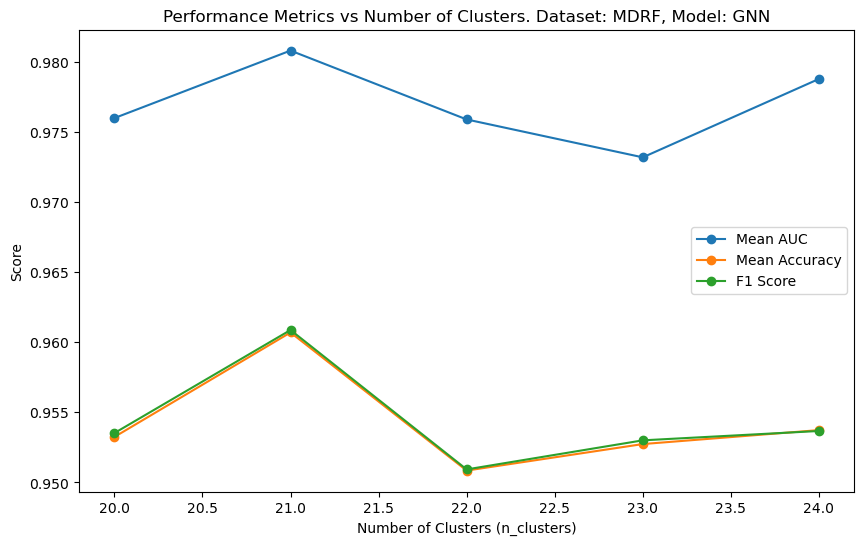

In [21]:
print(f"Dataset: {DATASET_NAME} | Total known associations: {adj_matrix.sum()}")
print(f"Model: {MODEL}")
results_df = pd.DataFrame(results_summary)

print("\n===== FINAL SUMMARY =====")
print(results_df)

results_df.to_csv("cluster_ablation_results.csv", index=False)

plt.figure(figsize=(10, 6))
plt.plot(results_df["n_clusters"], results_df["mean_auc"], marker='o', label='Mean AUC')
plt.plot(results_df["n_clusters"], results_df["mean_accuracy"], marker='o', label='Mean Accuracy')
plt.plot(results_df["n_clusters"], results_df["f1_score"], marker='o', label='F1 Score')
plt.xlabel("Number of Clusters (n_clusters)")
plt.ylabel("Score")
plt.legend()
plt.title(f"Performance Metrics vs Number of Clusters. Dataset: {DATASET_NAME}, Model: {MODEL}")
plt.show()
